# Advanced Policy Gradient Techniques

1. Environment Setup: Configured the BipedalWalker-v3 environment from Gymnasium with proper rendering support and seeded for reproducibility.
2. Replay Buffer: Implemented an experience replay buffer with GPU support for efficient batch sampling.
3. TD3 Algorithm Implementation: Implemented Twin Delayed Deep Deterministic Policy Gradient (TD3), an advanced policy gradient algorithm.
4. Training Pipeline: Developed a complete training loop with:
    - 500 training episodes
    - 1600 maximum steps per episode
    - Real-time learning curve visualization
    - 20-episode moving average tracking

5. Inference Testing: Conducted evaluation over 200 episodes to validate model performance against the threshold of 300 reward.
6. Model Visualization: Rendered and saved video demonstration of the trained policy in action.

## 0. Import and helper functions initialization

In [ ]:
!pip install swig
!pip install gymnasium[classic-control] gymnasium[box2d] pyvirtualdisplay
!apt-get install -y xvfb python-opengl ffmpeg
!apt-get install ffmpeg freeglut3-dev xvfb

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import ipywidgets as widgets
from IPython import display
from pyvirtualdisplay import Display
d = Display(visible=0, size=(400, 300))
d.start()

from copy import deepcopy
from collections import deque
import torch
from torch.autograd import Variable
from torch import nn
import random
import math
import torchvision.transforms as T
import numpy as np
import time
import gymnasium as gym, math
from gymnasium.utils.save_video import save_video

env = gym.make("BipedalWalker-v3", render_mode="rgb_array")

seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import base64
from pathlib import Path

def show_video(model, env):
  done = False
  total_reward = 0

  video_path = 'videos'

  observation, _ = env.reset()
  frames = []

  while not done:
      action = model.predict(observation)

      observation, reward, terminated, truncated, _ = env.step(action)
      total_reward += reward
      frames.append(env.render())
      done = terminated or truncated

  save_video(frames, video_path, fps=env.metadata["render_fps"], video_length=len(frames))
  env.close()

  # Render recording
  print(f'reward is {total_reward}')
  html = []
  for mp4 in Path(video_path).glob("{}*.mp4".format("")):
      video_b64 = base64.b64encode(mp4.read_bytes())
      html.append(
          """<video alt="{}" autoplay
                  loop controls style="height: 400px;">
                  <source src="data:video/mp4;base64,{}" type="video/mp4" />
              </video>""".format(
              mp4, video_b64.decode("ascii")
          )
      )
  display.display(display.HTML(data="<br>".join(html)))

In [ ]:
def inference(model, env, threshold, episodes=200):
  for i_episode in range(200):
    observation, _ = env.reset()
    rewards = 0
    state = observation

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [threshold, threshold], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="TD3")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('Inference')
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model.predict(observation)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        state = next_state
  print("done")

## 1. Environment setup

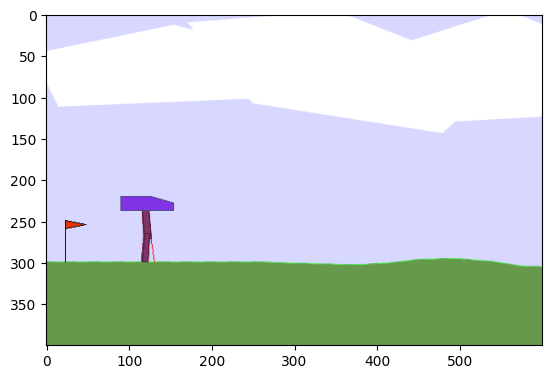

In [ ]:
obs, _ = env.reset()

plt.imshow(env.render())
plt.show()

## 2. Replay Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, max_size=int(1e6)):
        self.max_size = max_size
        self.buffer = deque(maxlen=max_size)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def push(self, state, action, reward, next_state, done):
        experience = (state, action, reward, next_state, done)
        self.buffer.append(experience)

    def sample(self, batch_size):
        state_batch = []
        action_batch = []
        reward_batch = []
        next_state_batch = []
        done_batch = []

        batch = random.sample(self.buffer, batch_size)

        for experience in batch:
            state, action, reward, next_state, done = experience
            state_batch.append(state)
            action_batch.append(action)
            reward_batch.append(reward)
            next_state_batch.append(next_state)
            done_batch.append(done)
        state_batch = torch.FloatTensor(np.array(state_batch)).to(self.device)
        action_batch = torch.FloatTensor(np.array(action_batch)).to(self.device)
        reward_batch = torch.FloatTensor(reward_batch).to(self.device).unsqueeze(1)
        next_state_batch = torch.FloatTensor(np.array(next_state_batch)).to(self.device)
        done_batch = torch.FloatTensor(done_batch).to(self.device).unsqueeze(1)

        return state_batch, action_batch, reward_batch, next_state_batch, done_batch

    def __len__(self):
        return len(self.buffer)

## 3. TD3 Implementation (Twin Delayed DDPG)

In [ ]:
# The actor is the same as in DDPG, it approximates policy
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh()
        )
        self.max_action = max_action

    def forward(self, state):
        return self.max_action * self.net(state)

# Critic in the TD3 consist of two Q-value approximators
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()

        # Q1
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Q2
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa), self.q2(sa)

    def q1_only(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa)

In [ ]:
class TD3():
  def __init__(
      self,
      state_dim,
      action_dim,
      max_action,
      gamma=0.99,
      tau=0.005,
      policy_noise=0.2,
      noise_clip=0.5,
      policy_delay=2,
      lr=3e-4
    ):
    self.actor = Actor(state_dim, action_dim, max_action).to(device)
    self.actor_target = deepcopy(self.actor)

    self.critic = Critic(state_dim, action_dim).to(device)
    self.critic_target = deepcopy(self.critic)

    self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=lr)
    self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=lr)

    self.max_action = max_action
    self.gamma = gamma
    self.tau = tau

    self.policy_noise = policy_noise
    self.noise_clip = noise_clip
    self.policy_delay = policy_delay

    self.total_it = 0

  def predict(self, state, noise=0.1):
    state = torch.FloatTensor(state).unsqueeze(0).to(device)
    action = self.actor(state).cpu().data.numpy().flatten()

    # Use additive Gaussian noise to the actions (replacing eps-greedy from Q-learning)
    if noise != 0:
      action += np.random.normal(0, noise, size=action.shape)

    return np.clip(action, -self.max_action, self.max_action)

  def train(self, replay_buffer, batch_size=256):
    self.total_it += 1
    state, action, reward, next_state, done = replay_buffer.sample(batch_size)

    with torch.no_grad():

        noise = (
            torch.randn_like(action) * self.policy_noise
        ).clamp(-self.noise_clip, self.noise_clip)

        # Added noise to target actions for smoother value estimates
        next_action = (
            self.actor_target(next_state) + noise
        ).clamp(-self.max_action, self.max_action)

        target_q1, target_q2 = self.critic_target(next_state, next_action)
        target_q = torch.min(target_q1, target_q2)
        target_q = reward + (1 - done) * self.gamma * target_q

    current_q1, current_q2 = self.critic(state, action)

    # MSBE loss with SGD
    critic_loss = (
        nn.MSELoss()(current_q1, target_q)
        + nn.MSELoss()(current_q2, target_q)
    )

    self.critic_optimizer.zero_grad()
    critic_loss.backward()
    self.critic_optimizer.step()

    # Update the actor network less frequently than the critic (every 2 critic updates)
    if self.total_it % self.policy_delay == 0:
        actor_loss = -self.critic.q1_only(
            state, self.actor(state)
        ).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # target networks' param update by polyak averaging
        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

## 4. Training

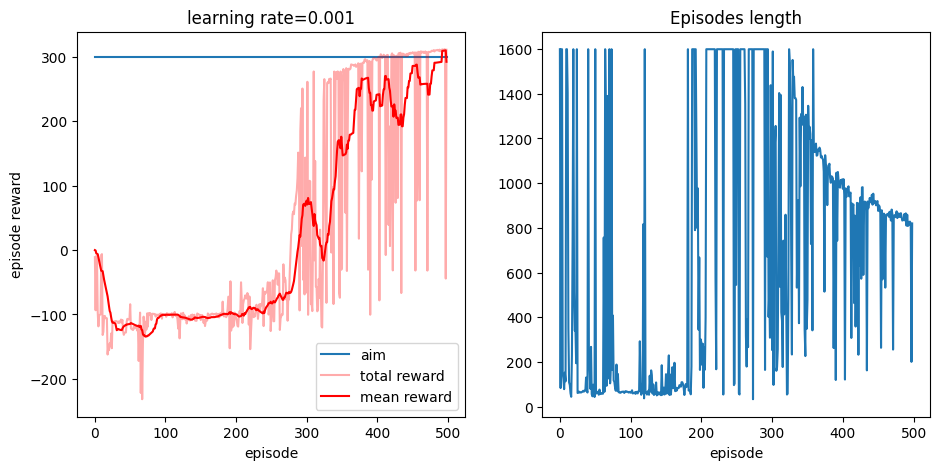

done


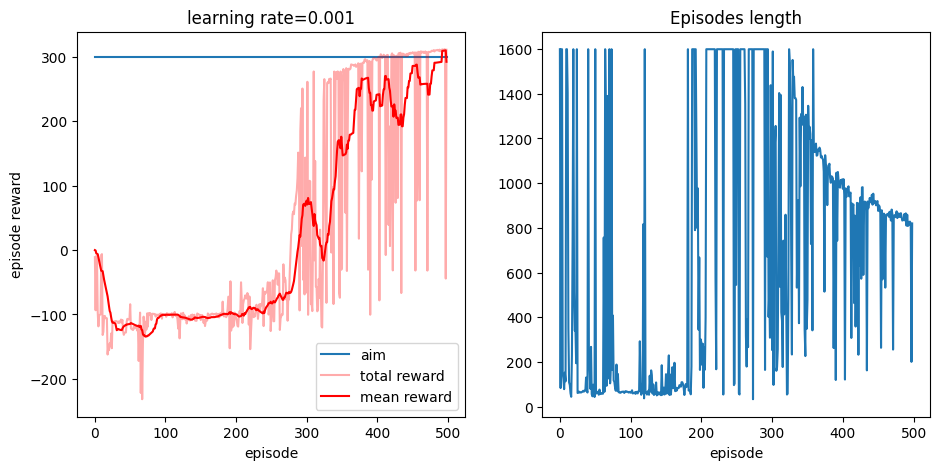

In [ ]:
env = gym.make("BipedalWalker-v3")

set_seed(seed)

# Q table
n_states = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# Learning Parameters
alpha = 1e-3

# Execution parameters
SHOW_ANIMATION = False
EPISODES_MAX = 500
STEPS_MAX = 1600

# Loggers
log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)
log_mean_reward = np.zeros(EPISODES_MAX)

model = TD3(
    n_states,
    n_actions,
    max_action
)
replay_buffer = ReplayBuffer(int(1e5))

# learning
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset(seed=seed)
    rewards = 0

    if (i_episode + 1) % 10 == 0:
        plt.figure(2, figsize=(11, 5))
        plt.clf()

        ax1 = plt.subplot(1, 2, 1)
        ax1.plot([0, i_episode], [300, 300], label="aim")
        ax1.plot(range(0, i_episode), log_total_reward[0:i_episode], label="total reward", c='r', alpha=0.33)
        ax1.plot(range(0, i_episode), log_mean_reward[0:i_episode], label="mean reward", c='r')
        ax1.set_xlabel('episode')
        ax1.set_ylabel('episode reward')
        plt.title('learning rate={}'.format(alpha))
        ax1.legend()

        ax2 = plt.subplot(1, 2, 2)
        ax2.plot(range(0, i_episode), log_steps_number[0:i_episode])
        ax2.set_xlabel('episode')
        ax2.set_title('Episodes length')

        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        action = model.predict(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)

        if len(replay_buffer) > 10000:
            model.train(replay_buffer)

        rewards += reward

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            last20rew = log_total_reward[max(i_episode-20, 0):i_episode]
            log_mean_reward[i_episode] = sum(last20rew)/20
            break

        # Update current state
        state = next_state

print("done")

## 5. Inference

Проверим, как работает обученная модель на 200 эпизодах - по заданию необходимо получать награду более 300 (threshold)

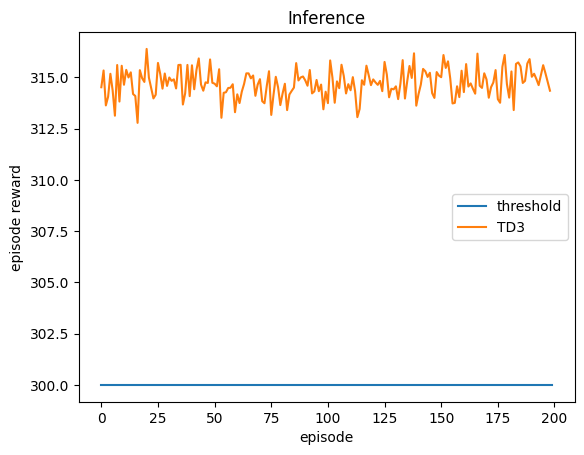

done


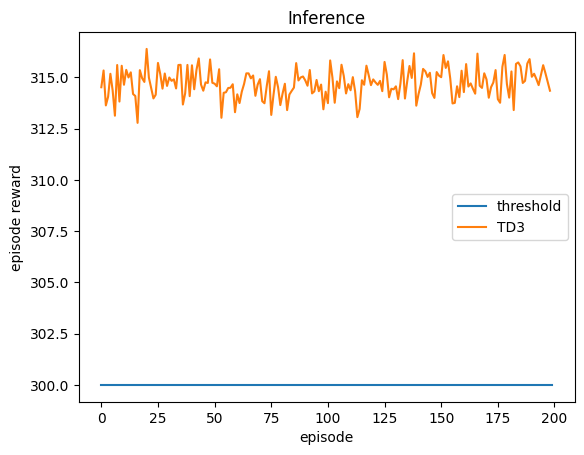

In [ ]:
inference(model, env, threshold=300)

## 6. Model visualization

In [ ]:
show_video(model, gym.make("BipedalWalker-v3", render_mode='rgb_array'))

reward is 314.24273681640625


TD3 algorithm successfully learned a robust walking policy for the BipedalWalker environment, demonstrating its suitability for high-dimensional continuous action spaces. Achieving an average reward of ~314 confirms that TD3 is a reliable solution for the BipedalWalker benchmark, making it a viable choice for similar continuous control problems in robotics and simulation. The modifications introduced in TD3 (twin critics, target smoothing, delayed updates) addressed the inherent instability issues found in standard DDPG.